----

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

In [2]:
#importar los archivos
#estudiar los datos que contienen
#asegurarte de que los tipos de datos sean correctos
sql_1 = pd.read_csv("project_sql_result_01.csv")

In [3]:
sql_1["company_name"] = sql_1["company_name"].str.lower()

In [4]:
sql_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [5]:
sql_1

,company_name,trips_amount
0,flash cab,19558
1,taxi affiliation services,11422
2,medallion leasin,10367
3,yellow cab,9888
4,taxi affiliation service yellow,9299
...,...,...
59,4053 - 40193 adwar h. nikola,7
60,2733 - 74600 benny jona,7
61,5874 - 73628 sergey cab corp.,5
62,"2241 - 44667 - felman corp, manuel alonso",3


In [6]:
print(f"Valores ausentes: {sql_1.isna().sum()}")

Valores ausentes: company_name    0
trips_amount    0
dtype: int64


In [7]:
print(f"Valores duplicados: {sql_1.duplicated().sum()}")

Valores duplicados: 0


In [8]:
print()

In [9]:
print()

In [10]:
#importar los archivos
#estudiar los datos que contienen
#asegurarte de que los tipos de datos sean correctos
sql_4 = pd.read_csv("project_sql_result_04.csv")

In [11]:
sql_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [12]:
sql_4

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
...,...,...
89,Mount Greenwood,3.137931
90,Hegewisch,3.117647
91,Burnside,2.333333
92,East Side,1.961538


In [13]:
print(f"Vlores ausentes: {sql_4.isna().sum()}")

Vlores ausentes: dropoff_location_name    0
average_trips            0
dtype: int64


In [14]:
print(f"Valores duplicados: {sql_4.duplicated().sum()}")

Valores duplicados: 0


In [15]:
#identificar los 10 principales barrios en términos de finalización del recorrido
sql_4.head(10)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


In [16]:
print()

In [17]:
print()

<function matplotlib.pyplot.show(close=None, block=None)>

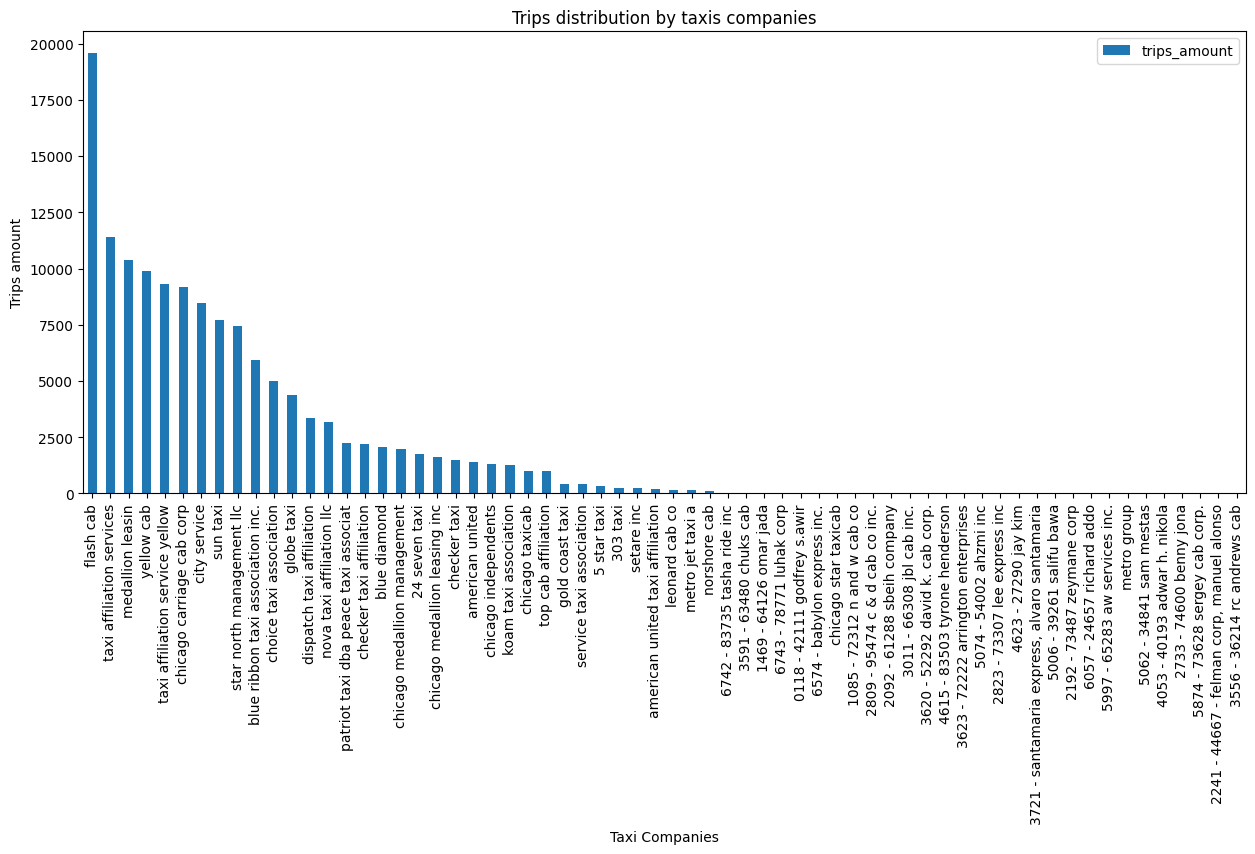

In [18]:
#hacer gráficos: empresas de taxis y número de viajes, los 10 barrios principales por número de finalizaciones
#sacar conclusiones basadas en cada gráfico y explicar los resultados

sql_1.plot(x="company_name", kind="bar", xlabel="Taxi Companies", ylabel="Trips amount", figsize=(15,6), title="Trips distribution by taxis companies")
plt.show

Hay 64 compañias de taxis referentes a la cantidad de viajes que hizo cada una, pero en el grafico se percibe la excepcion sobre ciertas empresas que no tuvieran ningun viaje. Practicamente poco mas de la mitad de registros de empresas de taxis quedan obsoletas en cuanto la consideracion de usar su servicio. Particularmente se caracterizan por ser empresas no reconocidas ya que principalmente se dan a conocer por el numero de la empresa y no por su nombre. Esencialmente eso podria definir la diferencia entre una compañia con experiencia, la cual se da a conocer por el nombre en si y no por el telefono, o minimo eso es lo que practicamente dice el grafico, justo porque todas las compañias que tienen solo el nombre y sin telefono, son las que si tuvieron viajes y las que tienen telefono y el nombre de su compañia no tuvieron ningun viaje. Parece ser que las empresas que tienen su numero de telefono junto con el nombre de su empresa, no tienen ningun tipo de experiencia, ya que son nuevas o todavia no tienen los recursos suficientes como para venderles sus servicios a los clientes.

In [19]:
sql_4_head = sql_4.sort_values("average_trips", ascending=False).head(10)
sql_4_head

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


<function matplotlib.pyplot.show(close=None, block=None)>

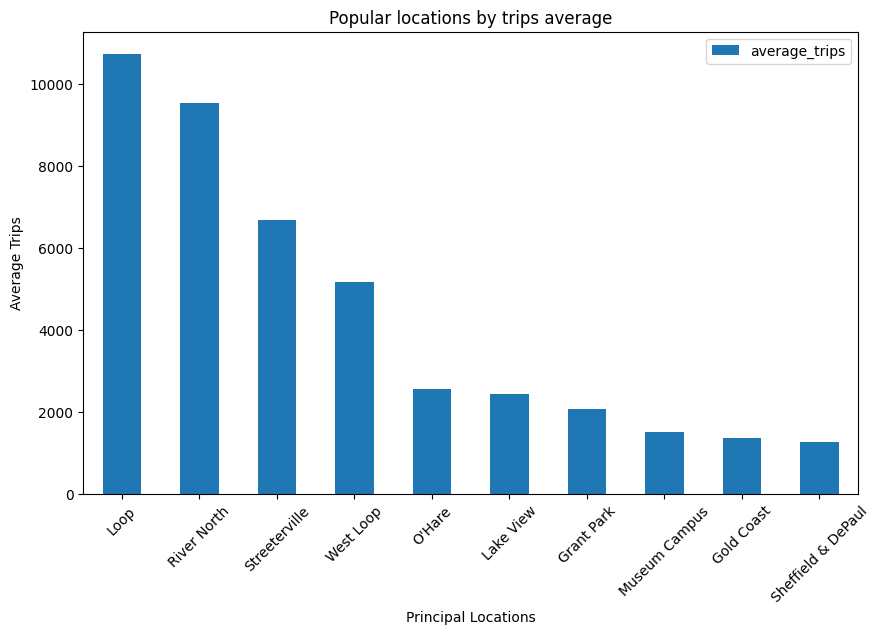

In [20]:
sql_4_head.plot(x="dropoff_location_name", kind="bar", xlabel="Principal Locations", ylabel="Average Trips", figsize=(10,6), rot=45, title="Popular locations by trips average")
plt.show

Loop es el barrio principal por ser el destino final de viajes por taxi de la mayoria de gente, mas que cualquier otro barrio, Loop domina completamente. Se debate un poco con River North y no por mucho, tambien se puede decir que es otro barrio que domina en cuanto destinos. Es curioso ver como la concentracion geografica se basa en los primeros cuatro, y digo 4 porque a partir de West Loop, tiene una caida muy pronunciada empezando por el aeropuerto "O'Hare" lo que hace sentido, el aeropuerto representa un patron diferente de demanda, por lo que infiero a que las zonas centrales comerciales estan dentro de estos 4 principales barrios y es por eso que hay mas cantidad de viaje hacia estos destinos. En cuanto a como se debate la cantidad de destinos entre los dos principales barrios, podria inferir a que es por preferencias en cuanto a si es turistico uno a diferencia del otro, o si tienen implementaciones de infraestructura de comercios.

In [21]:
print()

In [22]:
print()

In [23]:
#Paso 5. Prueba de hipótesis (Python)
#/datasets/project_sql_result_07.csv — el resultado de la última consulta.
#Contiene datos sobre viajes desde el Loop hasta el Aeropuerto Internacional O'Hare.
#Recuerda, estos son los valores de campo de la tabla:

In [24]:
sql_7 = pd.read_csv("project_sql_result_07.csv")

In [25]:
sql_7["start_ts"] = pd.to_datetime(sql_7["start_ts"])

In [26]:
sql_7["duration_seconds"] = sql_7["duration_seconds"].astype("int64")

In [27]:
sql_7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 25.2+ KB


In [28]:
sql_7

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410
1,2017-11-25 14:00:00,Good,1920
2,2017-11-25 12:00:00,Good,1543
3,2017-11-04 10:00:00,Good,2512
4,2017-11-11 07:00:00,Good,1440
...,...,...,...
1063,2017-11-25 11:00:00,Good,0
1064,2017-11-11 10:00:00,Good,1318
1065,2017-11-11 13:00:00,Good,2100
1066,2017-11-11 08:00:00,Good,1380


In [29]:
print(f"Valores duplicados: {sql_7.duplicated().sum()}")

Valores duplicados: 197


In [30]:
print(f"Valores ausentes por columna: {sql_7.isna().sum()}")

Valores ausentes por columna: start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64


In [31]:
sql_7 = sql_7.drop_duplicates()

In [32]:
sql_7

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410
1,2017-11-25 14:00:00,Good,1920
2,2017-11-25 12:00:00,Good,1543
3,2017-11-04 10:00:00,Good,2512
4,2017-11-11 07:00:00,Good,1440
...,...,...,...
1060,2017-11-04 14:00:00,Good,2700
1061,2017-11-18 16:00:00,Bad,2186
1063,2017-11-25 11:00:00,Good,0
1064,2017-11-11 10:00:00,Good,1318


In [33]:
print()

In [34]:
print()

Hipotesis Alternativa: "La duracion en promedio de viajes desde el barrio Loop, hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos"

In [35]:
df_good = sql_7[sql_7["weather_conditions"] == "Good"]
df_good

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410
1,2017-11-25 14:00:00,Good,1920
2,2017-11-25 12:00:00,Good,1543
3,2017-11-04 10:00:00,Good,2512
4,2017-11-11 07:00:00,Good,1440
...,...,...,...
1057,2017-11-04 12:00:00,Good,2492
1059,2017-11-11 10:00:00,Good,1303
1060,2017-11-04 14:00:00,Good,2700
1063,2017-11-25 11:00:00,Good,0


In [36]:
promedio_df_good = df_good["duration_seconds"].mean()
print("(Hipotesis Alternativa)")
print()
print(f"Duracion promedio de viajes con clima despejado en sabados: {promedio_df_good}")

(Hipotesis Alternativa)

Duracion promedio de viajes con clima despejado en sabados: 2032.253112033195


In [37]:
print()

In [38]:
print()

Hipotesis Nula: "La duracion en promedio de viajes desde el barrio Loop, hasta el Aeropuerto Internacional O'Hare NO cambia los sábados lluviosos"

In [39]:
df_bad = sql_7[sql_7["weather_conditions"] == "Bad"]
df_bad

,start_ts,weather_conditions,duration_seconds
6,2017-11-04 16:00:00,Bad,2969
30,2017-11-18 12:00:00,Bad,1980
34,2017-11-04 17:00:00,Bad,2460
51,2017-11-04 16:00:00,Bad,2760
52,2017-11-18 12:00:00,Bad,2460
...,...,...,...
1031,2017-11-18 12:00:00,Bad,2560
1032,2017-11-18 10:00:00,Bad,1908
1053,2017-11-18 12:00:00,Bad,2400
1061,2017-11-18 16:00:00,Bad,2186


In [40]:
promedio_df_bad = df_bad["duration_seconds"].mean()
print("(Hipotesis Nula)")
print()
print(f"Duracion promedio de viajes con clima lluvioso en sabados: {promedio_df_bad}")

(Hipotesis Nula)

Duracion promedio de viajes con clima lluvioso en sabados: 2409.2297297297296


In [41]:
print()

In [42]:
print()

In [43]:
results = st.ttest_ind(df_good["duration_seconds"], df_bad["duration_seconds"])
p_value = results.pvalue

In [44]:
p_value

np.float64(7.397770692813658e-08)

Referente al valor p, establezco el umbral como se determinaria de manera standard. Si alpha lo considero como 0.05 siendo asi 5%, comparado con el valor "p", puedo concluir que es mucho menos al umbral designado (5%), por lo que se rechaza la hipotesis nula y se acepta la alternativa por bastante diferencia, ya que el valor "p" es demasiado bajo en comparacion al umbral, asumiendo que hay mucha diferencia.